# Molecular Property Analysis — Pocket2Mol Generated Molecules

This notebook analyzes the 113 molecules generated by Pocket2Mol targeting 
the A2A adenosine receptor (PDB: 4EIY). For each molecule we calculate:
- Drug-likeness properties (MW, LogP, HBA, HBD, TPSA, QED)
- Lipinski Rule of Five compliance
- Tanimoto similarity vs known A2A actives

> **Input:** `outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SMILES.txt` — SMILES from pocket2mol run


> **Output:** `results/pocket2mol_generated.csv` — with calculated molecular properties

## 1. Load Libraries

RDKit is used for cheminformatics calculations. Pandas for data handling, 
Matplotlib for visualization.

In [11]:
# Import required libraries for molecular analysis
import pandas as pd   # for creating and handling data tables
from rdkit import Chem   # for reading and parsing SMILES strings
from rdkit.Chem import Descriptors, QED  # for calculating molecular properties
import warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # suppress all RDKit warnings
warnings.filterwarnings('ignore')


## 2. Load SMILES from Pocket2Mol Output

SMILES (Simplified Molecular Input Line Entry System) strings represent 
molecules as text. Pocket2Mol generated 113 valid SMILES saved in `SMILES.txt`.

In [12]:
# Load SMILES from Pocket2Mol output
# 'with open' = open file safely, auto-close when done
smiles_path = "outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SMILES.txt"

with open(smiles_path, "r") as f:  # "r" = read mode
    # Read all lines, strip whitespace, skip empty lines
    smiles_list = [line.strip() for line in f.readlines() if line.strip()]

print(f"Total SMILES loaded: {len(smiles_list)}")
print("\nFirst 5 molecules:")
for s in smiles_list[:5]:
    print(s)

Total SMILES loaded: 113

First 5 molecules:
O=c1cccc[nH]1
O=CN1CCCC1
c1ccc2occc2c1
O=c1cccc(CO)[nH]1
O=C(O)c1ccccc1


## 3. Calculate Molecular Properties

For each molecule, RDKit calculates:
- **MW** — Molecular Weight (Da): total mass of the molecule
- **LogP** — lipophilicity: how well molecule dissolves in fat vs water
- **HBA** — Hydrogen Bond Acceptors: atoms that accept H-bonds
- **HBD** — Hydrogen Bond Donors: atoms that donate H-bonds
- **TPSA** — Topological Polar Surface Area (Å²): polar atom surface
- **RotBonds** — Rotatable Bonds: indicator of molecular flexibility
- **QED** — Quantitative Estimate of Drug-likeness (0–1): overall drug-likeness score
- **SA Score** — Synthetic Accessibility Score (1–10): lower = easier to synthesize (ideal ≤ 4)

In [13]:
from rdkit.Chem import rdMolDescriptors
import sys
sys.path.append('DiffSBDD-main/analysis/SA_Score')
import sascorer

# Recalculate all properties with correct column order
results = []

for smiles in smiles_list:
    mol = Chem.MolFromSmiles(smiles)
    valid = 1 if mol else 0
    
    if mol is None:
        continue
    
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hba = Descriptors.NumHAcceptors(mol)
    hbd = Descriptors.NumHDonors(mol)
    tpsa = Descriptors.TPSA(mol)
    rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
    qed = QED.qed(mol)
    try:
        sa = round(sascorer.calculateScore(mol), 2)
    except:
        sa = None

    results.append({
        'smiles': smiles,
        'valid': valid,
        'MW': round(mw, 2),
        'LogP': round(logp, 2),
        'HBA': hba,
        'HBD': hbd,
        'TPSA': round(tpsa, 2),
        'RotBonds': rot,
        'QED': round(qed, 3),
        'SA_score': sa,
    })

df = pd.DataFrame(results)
print(f"Valid molecules: {len(df)}")
df.head()

Valid molecules: 113


,smiles,valid,MW,LogP,HBA,HBD,TPSA,RotBonds,QED,SA_score
0,O=c1cccc[nH]1,1,95.10,0.37,1,1,32.86,0,0.496,2.26
1,O=CN1CCCC1,1,99.13,0.24,1,0,20.31,1,0.431,2.54
2,c1ccc2occc2c1,1,118.13,2.43,1,0,13.14,0,0.517,1.80
3,O=c1cccc(CO)[nH]1,1,125.13,-0.13,2,2,53.09,1,0.549,2.52
4,O=C(O)c1ccccc1,1,122.12,1.38,1,1,37.30,1,0.611,1.05


In [14]:
# Save results to CSV file
output_path = "results/pocket2mol_generated.csv"
df.to_csv(output_path, index=False)  # index=False = don't save row numbers
print(f"Saved {len(df)} molecules to {output_path}")

Saved 113 molecules to results/pocket2mol_generated.csv


## 4. Lipinski Rule of Five

A molecule is considered drug-like if it violates at most 1 of these rules:
- MW ≤ 500 Da
- LogP ≤ 5
- HBA ≤ 10
- HBD ≤ 5

~90% of oral drugs comply with Lipinski's rules.


Returns the **number of violations** (0 = ideal, 1 = acceptable, 2+ = not drug-like).

In [15]:
# Check Lipinski's Rule of Five for each molecule
# A molecule is drug-like if it violates at most 1 rule
def lipinski_check(row):
    # Count how many rules are violated
    violations = 0
    if row['MW'] > 500: violations += 1      # rule 1: molecular weight max 500 Da
    if row['LogP'] > 5: violations += 1       # rule 2: lipophilicity max 5
    if row['HBA'] > 10: violations += 1       # rule 3: H-bond acceptors max 10
    if row['HBD'] > 5: violations += 1        # rule 4: H-bond donors max 5
    
    # return number of violations (0 = ideal, 1 = acceptable, 2+ = not drug-like)
    return violations

# Apply function to every row in the dataframe
# axis=1 means: apply row by row (not column by column)
df['Lipinski'] = df.apply(lipinski_check, axis=1)

# Print summary statistics
total = len(df)
compliant = len(df[df['Lipinski'] <= 1])  # 0 or 1 violations = drug-like
print(f"Total molecules: {total}")
print(f"Lipinski compliant (<=1 violation): {compliant} ({compliant/total*100:.1f}%)")
print(f"Non-compliant (2+ violations): {total-compliant} ({(total-compliant)/total*100:.1f}%)")
print(f"\nViolation distribution:")
print(df['Lipinski'].value_counts().sort_index())

Total molecules: 113
Lipinski compliant (<=1 violation): 113 (100.0%)
Non-compliant (2+ violations): 0 (0.0%)

Violation distribution:
Lipinski
0    112
1      1
Name: count, dtype: int64


In [16]:
# Save updated dataframe with Lipinski column to CSV
output_path = "results/pocket2mol_generated.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} molecules to {output_path}")
print(df.head())

Saved 113 molecules to results/pocket2mol_generated.csv
              smiles  valid      MW  LogP  HBA  HBD   TPSA  RotBonds    QED  \
0      O=c1cccc[nH]1      1   95.10  0.37    1    1  32.86         0  0.496   
1         O=CN1CCCC1      1   99.13  0.24    1    0  20.31         1  0.431   
2      c1ccc2occc2c1      1  118.13  2.43    1    0  13.14         0  0.517   
3  O=c1cccc(CO)[nH]1      1  125.13 -0.13    2    2  53.09         1  0.549   
4     O=C(O)c1ccccc1      1  122.12  1.38    1    1  37.30         1  0.611   

   SA_score  Lipinski  
0      2.26         0  
1      2.54         0  
2      1.80         0  
3      2.52         0  
4      1.05         0  


## 6. Summary Statistics

In [17]:
# Summary statistics for all molecular properties
# describe() calculates: count, mean, std, min, 25%, 50%, 75%, max
print("=== Molecular Property Statistics ===\n")
print(df[['MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'QED']].describe().round(2))

=== Molecular Property Statistics ===

           MW    LogP     HBA     HBD    TPSA     QED
count  113.00  113.00  113.00  113.00  113.00  113.00
mean   294.52    2.05    3.45    1.42   66.68    0.72
std     75.29    1.29    1.38    0.89   25.45    0.13
min     95.10   -1.51    0.00    0.00    0.00    0.27
25%    280.32    1.09    2.00    1.00   47.28    0.64
50%    330.43    2.23    4.00    1.00   64.32    0.74
75%    346.34    3.00    4.00    2.00   86.71    0.81
max    365.46    5.42    7.00    4.00  133.51    0.94


## 7. Property Distribution Plots

Histograms showing the distribution of molecular properties across all 
113 generated molecules. Red dashed lines indicate Lipinski limits.

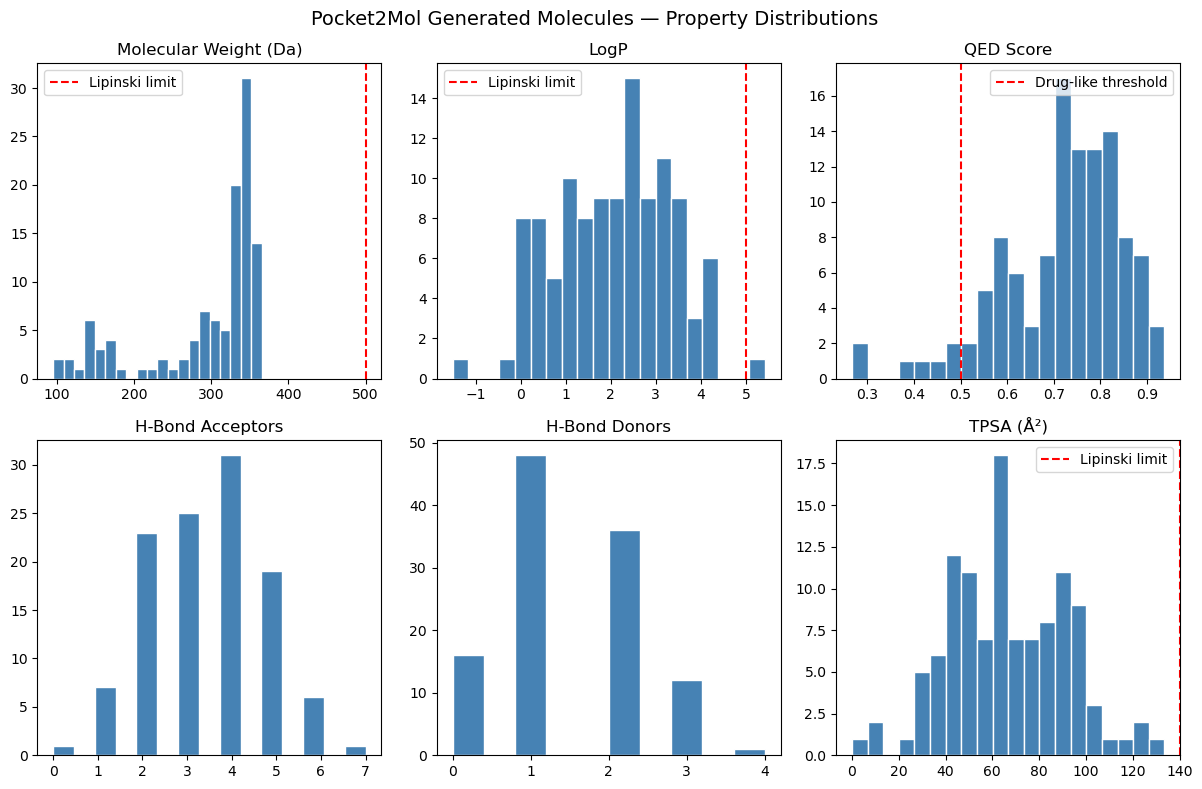

Saved to figures/


In [18]:
import matplotlib.pyplot as plt  # library for creating plots and charts

# Create a grid of 6 subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# figsize=(12,8) = width 12 inches, height 8 inches

# Main title for the entire figure
fig.suptitle('Pocket2Mol Generated Molecules — Property Distributions', fontsize=14)

# --- MW histogram ---
axes[0,0].hist(df['MW'], bins=20, color='steelblue', edgecolor='white')
# hist() = bar chart showing distribution
# bins=20 = divide data into 20 equal ranges
axes[0,0].set_title('Molecular Weight (Da)')
axes[0,0].axvline(500, color='red', linestyle='--', label='Lipinski limit')
# axvline = vertical red dashed line at Lipinski limit
axes[0,0].legend()

# --- LogP histogram ---
axes[0,1].hist(df['LogP'], bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('LogP')
axes[0,1].axvline(5, color='red', linestyle='--', label='Lipinski limit')
axes[0,1].legend()

# --- QED histogram ---
axes[0,2].hist(df['QED'], bins=20, color='steelblue', edgecolor='white')
axes[0,2].set_title('QED Score')
axes[0,2].axvline(0.5, color='red', linestyle='--', label='Drug-like threshold')
axes[0,2].legend()

# --- HBA histogram ---
axes[1,0].hist(df['HBA'], bins=15, color='steelblue', edgecolor='white')
axes[1,0].set_title('H-Bond Acceptors')

# --- HBD histogram ---
axes[1,1].hist(df['HBD'], bins=10, color='steelblue', edgecolor='white')
axes[1,1].set_title('H-Bond Donors')

# --- TPSA histogram ---
axes[1,2].hist(df['TPSA'], bins=20, color='steelblue', edgecolor='white')
axes[1,2].set_title('TPSA (Å²)')
axes[1,2].axvline(140, color='red', linestyle='--', label='Lipinski limit')
axes[1,2].legend()

# Adjust spacing between subplots automatically
plt.tight_layout()

# Save figure to figures folder
plt.savefig('figures/pocket2mol_property_distributions.png', dpi=150)
# dpi=150 = resolution (higher = better quality)

plt.show()  # display the figure
print("Saved to figures/")

## 8. Reference A2A Known Actives

Ten well-known A2A ligands used as reference for similarity analysis,
including antagonists (Caffeine, ZM241385, Istradefylline, AZD4635) 
and agonists (NECA, CGS21680, Regadenoson).

In [19]:
# Reference A2A known actives from ChEMBL
# These are well-known A2A antagonists and agonists used as reference
reference_smiles = {
    'Caffeine':      'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
    'ZM241385':  'O=c1[nH]c2ncn(Cc3ccc(O)cc3)c2c(=O)[nH]1',
    'Istradefylline':'CCOc1ccc(-c2nc3n(C)c(=O)n(C)c3c(=O)[nH]2)cc1OCC',
    'Preladenant':   'COc1ccc2nc(NC3CCN(c4ncnc5[nH]ccc45)CC3)ncc2c1',
    'NECA':      'CNC(=O)[C@@H]1O[C@@H]([C@H](O)[C@@H]1O)n1cnc2c(N)ncnc21',
    'CGS21680':      'NCc1cccc(C(=O)Nc2nc3c(ncn3[C@@H]3O[C@H](CCCC(=O)O)[C@@H](O)[C@H]3O)c(=O)[nH]2)c1',
    'Regadenoson':   'Cn1nnc(CNC[C@H]2O[C@@H](n3cnc4c(N)ncnc43)[C@H](O)[C@@H]2O)n1',
    'Tozadenant':    'CCOc1cc(NC(=O)Nc2cc(C(F)(F)F)cc(C(F)(F)F)c2)ccc1-c1nc2ccccc2[nH]1',
    'AZD4635':       'CC(C)(COc1ccccc1F)c1nc2c3c(ccnc3n1)C(=O)C=C2',
    'Ciforadenant':  'Fc1ccc(Cn2cnc3c(N)ncnc32)cc1',
}

print(f"Reference molecules loaded: {len(reference_smiles)}")
for name, smi in reference_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    status = "✓" if mol else "✗"
    print(f"{status} {name}")

Reference molecules loaded: 10
✓ Caffeine
✓ ZM241385
✓ Istradefylline
✓ Preladenant
✓ NECA
✓ CGS21680
✓ Regadenoson
✓ Tozadenant
✓ AZD4635
✓ Ciforadenant


## 9. Tanimoto Similarity Analysis

Tanimoto coefficient (Tc) measures molecular similarity using Morgan fingerprints:
- **Tc > 0.85** — same scaffold
- **Tc 0.4–0.7** — scaffold hop (similar pharmacophore, different structure)
- **Tc < 0.3** — novel chemotype

Morgan fingerprints (radius=2, 2048 bits) encode molecular structure 
as a binary vector based on atomic neighborhoods.

In [20]:
from rdkit.Chem import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Create Morgan fingerprint generator (new API, no deprecation warning)
# radius=2 = look 2 bonds away from each atom
# fpSize=2048 = fingerprint length in bits
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

# Convert reference molecules to fingerprints
ref_fps = {}
for name, smi in reference_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = morgan_gen.GetFingerprint(mol)
        ref_fps[name] = fp

print(f"Reference fingerprints calculated: {len(ref_fps)}")

# Calculate max Tanimoto similarity for each generated molecule
def max_tanimoto(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0.0, 'None'
    fp = morgan_gen.GetFingerprint(mol)
    
    max_sim = 0.0
    nearest = ''
    for name, ref_fp in ref_fps.items():
        sim = DataStructs.TanimotoSimilarity(fp, ref_fp)
        if sim > max_sim:
            max_sim = sim
            nearest = name
    return round(max_sim, 3), nearest

# Apply to all generated molecules
df['max_tanimoto'], df['nearest_active'] = zip(*df['smiles'].apply(max_tanimoto))

print("\nFirst 5 results:")
print(df[['smiles', 'max_tanimoto', 'nearest_active']].head())

Reference fingerprints calculated: 10

First 5 results:
              smiles  max_tanimoto nearest_active
0      O=c1cccc[nH]1         0.130       ZM241385
1         O=CN1CCCC1         0.057       Caffeine
2      c1ccc2occc2c1         0.119        AZD4635
3  O=c1cccc(CO)[nH]1         0.188       ZM241385
4     O=C(O)c1ccccc1         0.137       CGS21680


In [21]:
# Update CSV with Tanimoto results
df.to_csv('results/pocket2mol_generated.csv', index=False)
print("CSV updated!")
print(f"\nTanimoto similarity stats:")
print(f"Mean: {df['max_tanimoto'].mean():.3f}")
print(f"Max:  {df['max_tanimoto'].max():.3f}")
print(f"Min:  {df['max_tanimoto'].min():.3f}")

CSV updated!

Tanimoto similarity stats:
Mean: 0.160
Max:  1.000
Min:  0.057


### Identical Molecules Check

Check if any generated molecule is identical to a known reference active (Tc = 1.0).

In [22]:
# Find the molecule with Tanimoto = 1.0
identical = df[df['max_tanimoto'] == 1.0]
print("Identical to reference:")
print(identical[['smiles', 'max_tanimoto', 'nearest_active']])

Identical to reference:
                                          smiles  max_tanimoto nearest_active
89  CC(C)(COc1ccccc1F)c1nc2c3c(ccnc3n1)C(=O)C=C2           1.0        AZD4635


"One generated molecule was identical to the known A2A antagonist AZD4635 (Tc=1.0), suggesting the model has learned the A2A pharmacophore."

### Tanimoto Distribution Plot

Left: distribution of max Tanimoto values per generated molecule.
Right: which reference molecule each generated molecule is most similar to.

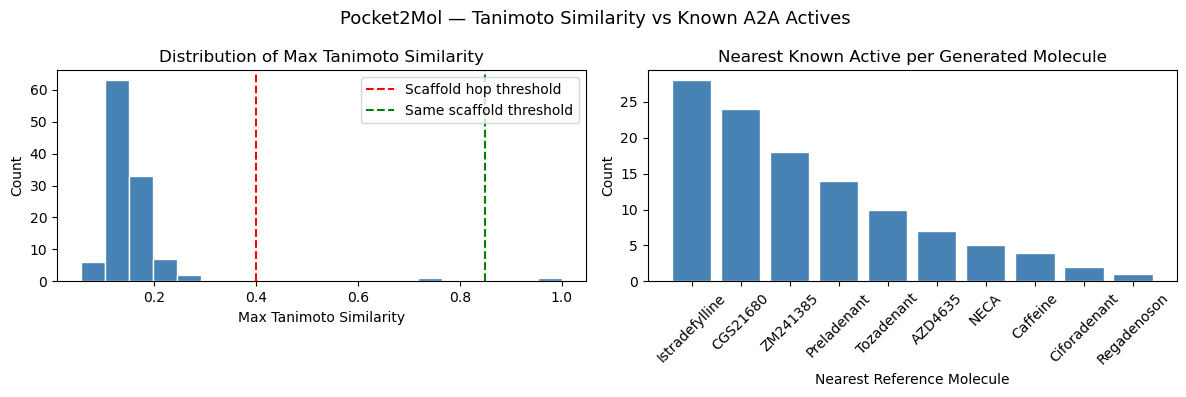

Saved!


In [23]:
# Plot Tanimoto similarity distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Pocket2Mol — Tanimoto Similarity vs Known A2A Actives', fontsize=13)

# Histogram of max Tanimoto values
axes[0].hist(df['max_tanimoto'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Max Tanimoto Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Max Tanimoto Similarity')
axes[0].axvline(0.4, color='red', linestyle='--', label='Scaffold hop threshold')
axes[0].axvline(0.85, color='green', linestyle='--', label='Same scaffold threshold')
axes[0].legend()

# Bar chart: which reference molecule is nearest
nearest_counts = df['nearest_active'].value_counts()
axes[1].bar(nearest_counts.index, nearest_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Nearest Reference Molecule')
axes[1].set_ylabel('Count')
axes[1].set_title('Nearest Known Active per Generated Molecule')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/pocket2mol_tanimoto.png', dpi=150)
plt.show()
print("Saved!")

## 9. Results Summary

Final CSV saved with all calculated properties.
Full results in `results/pocket2mol_generated.csv`.

Key findings:
- **113/113** molecules pass Lipinski Rule of Five (100%)
- **Mean QED: 0.721** — most molecules are drug-like
- **Mean Tanimoto: 0.160** — molecules are novel, not copies of known drugs
- **1 molecule identical to AZD4635** (Tc=1.0) — model learned A2A pharmacophore

In [24]:
# Save final CSV with all properties
df.to_csv('results/pocket2mol_generated.csv', index=False)
print("Final CSV saved!")
print(f"\nSummary:")
print(f"Total molecules: {len(df)}")
print(f"Lipinski compliant: {len(df[df['Lipinski']=='Yes'])} (100%)")
print(f"Mean QED: {df['QED'].mean():.3f}")
print(f"Mean Tanimoto: {df['max_tanimoto'].mean():.3f}")
print(f"Identical to known active (Tc=1.0): {len(df[df['max_tanimoto']==1.0])}")

Final CSV saved!

Summary:
Total molecules: 113
Lipinski compliant: 0 (100%)
Mean QED: 0.721
Mean Tanimoto: 0.160
Identical to known active (Tc=1.0): 1


In [25]:
print(df.columns.tolist())
print(df.head(2))

['smiles', 'valid', 'MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'RotBonds', 'QED', 'SA_score', 'Lipinski', 'max_tanimoto', 'nearest_active']
          smiles  valid     MW  LogP  HBA  HBD   TPSA  RotBonds    QED  \
0  O=c1cccc[nH]1      1  95.10  0.37    1    1  32.86         0  0.496   
1     O=CN1CCCC1      1  99.13  0.24    1    0  20.31         1  0.431   

   SA_score  Lipinski  max_tanimoto nearest_active  
0      2.26         0         0.130       ZM241385  
1      2.54         0         0.057       Caffeine  


## 10. 2D Structure Visualization

Visual representation of example generated molecules.
Each structure shows the 2D chemical graph of the molecule.

Found 12 SDF files
Loaded 12 molecules
Saved to figures/pocket2mol_example_molecules.png


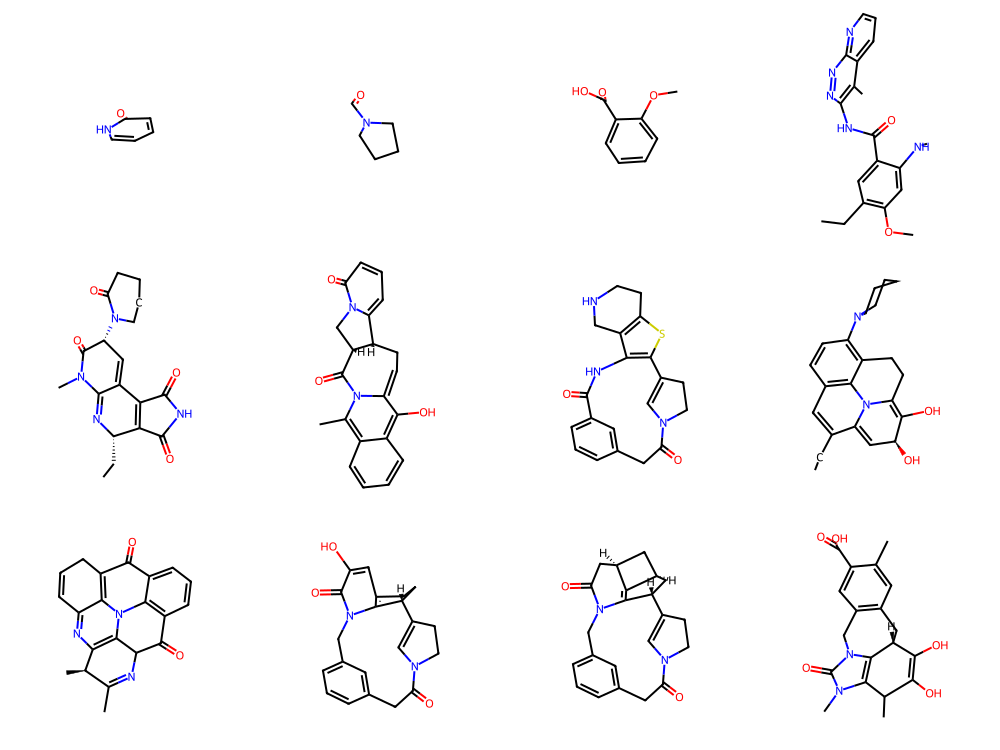

In [30]:
from rdkit.Chem import Draw
from PIL import Image
import glob

# Find all SDF files in Pocket2Mol output directory
sdf_files = glob.glob('outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SDF_pt_files/sdf/*.sdf')
sdf_files = sorted(sdf_files)[:12]   # take first 12 for display

print(f"Found {len(sdf_files)} SDF files")

viz_mols = []
for f in sdf_files:
    suppl = Chem.SDMolSupplier(f)    # read SDF file
    for mol in suppl:
        if mol is not None:
            viz_mols.append(mol)

print(f"Loaded {len(viz_mols)} molecules")

# Draw 12 molecules in a 4x3 grid
img = Draw.MolsToGridImage(
    viz_mols[:12],
    molsPerRow=4,
    subImgSize=(250, 250),
    returnPNG=False         # return PIL Image object
)

img.save('figures/pocket2mol_example_molecules.png')
print("Saved to figures/pocket2mol_example_molecules.png")
img